In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (classification_report, confusion_matrix, 
                             roc_curve, roc_auc_score, accuracy_score,
                             precision_score, recall_score, f1_score)
from sklearn.preprocessing import LabelEncoder, StandardScaler
import warnings
warnings.filterwarnings('ignore')

# Set plotting style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

In [3]:
# Load the credit risk dataset
# First check available files
import os
print("Available files:")
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# Load the data - adjust path as needed
df = pd.read_csv('/kaggle/input/credit-risk-dataset/credit_risk_dataset.csv')

print("\nDataset Shape:", df.shape)
print("\nFirst few rows:")
print(df.head())

print("\nData Types and Missing Values:")
print(df.info())

print("\nMissing values per column:")
print(df.isnull().sum())

print("\nBasic Statistics:")
print(df.describe())

Available files:
/kaggle/input/credit-risk-dataset/credit_risk_dataset.csv

Dataset Shape: (32581, 12)

First few rows:
   person_age  person_income person_home_ownership  person_emp_length  \
0          22          59000                  RENT              123.0   
1          21           9600                   OWN                5.0   
2          25           9600              MORTGAGE                1.0   
3          23          65500                  RENT                4.0   
4          24          54400                  RENT                8.0   

  loan_intent loan_grade  loan_amnt  loan_int_rate  loan_status  \
0    PERSONAL          D      35000          16.02            1   
1   EDUCATION          B       1000          11.14            0   
2     MEDICAL          C       5500          12.87            1   
3     MEDICAL          C      35000          15.23            1   
4     MEDICAL          C      35000          14.27            1   

   loan_percent_income cb_person_defau

Target Variable Distribution:
loan_status
0    25473
1     7108
Name: count, dtype: int64

Percentage:
loan_status
0    78.183604
1    21.816396
Name: proportion, dtype: float64

Overall Default Rate: 21.82%


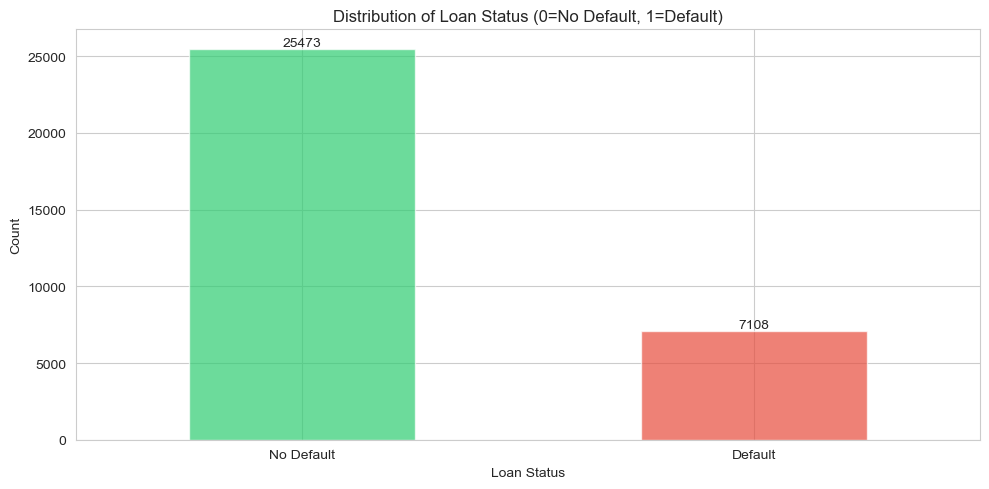

In [4]:
print("Target Variable Distribution:")
print(df['loan_status'].value_counts())
print("\nPercentage:")
print(df['loan_status'].value_counts(normalize=True) * 100)

default_rate = df['loan_status'].mean() * 100
print(f"\nOverall Default Rate: {default_rate:.2f}%")

# Visualize target distribution
plt.figure(figsize=(10, 5))
df['loan_status'].value_counts().plot(kind='bar', color=['#2ecc71', '#e74c3c'], alpha=0.7)
plt.xlabel('Loan Status')
plt.ylabel('Count')
plt.title('Distribution of Loan Status (0=No Default, 1=Default)')
plt.xticks([0, 1], ['No Default', 'Default'], rotation=0)
for i, v in enumerate(df['loan_status'].value_counts().values):
    plt.text(i, v, str(v), ha='center', va='bottom')
plt.tight_layout()
plt.show()

In [5]:
print("Data Cleaning:")
print(f"Initial shape: {df.shape}")

# Check for unrealistic values
print("\nAge statistics:")
print(df['person_age'].describe())

# Remove unrealistic ages (e.g., > 100 years)
df = df[df['person_age'] <= 100]

# Check employment length
print("\nEmployment length statistics:")
print(df['person_emp_length'].describe())

# Remove unrealistic employment lengths (e.g., > 50 years)
df = df[df['person_emp_length'] <= 50]

print(f"\nFinal shape after cleaning: {df.shape}")

# Handle missing values
df = df.dropna()
print(f"Shape after removing missing values: {df.shape}")

# The cleaning above changes the population, so the default rate quoted in the
# summary at the end of this notebook has to be recomputed here rather than reusing
# the pre-cleaning value calculated above
default_rate = df['loan_status'].mean() * 100
print(f"Default rate after cleaning: {default_rate:.2f}%")

Data Cleaning:
Initial shape: (32581, 12)

Age statistics:
count    32581.000000
mean        27.734600
std          6.348078
min         20.000000
25%         23.000000
50%         26.000000
75%         30.000000
max        144.000000
Name: person_age, dtype: float64

Employment length statistics:
count    31681.000000
mean         4.789527
std          4.142706
min          0.000000
25%          2.000000
50%          4.000000
75%          7.000000
max        123.000000
Name: person_emp_length, dtype: float64

Final shape after cleaning: (31679, 12)
Shape after removing missing values: (28632, 12)
Default rate after cleaning: 21.66%


In [6]:
print("Key Statistics by Loan Status:")
print("=" * 60)

# Compare defaulters vs non-defaulters
defaulters = df[df['loan_status'] == 1]
non_defaulters = df[df['loan_status'] == 0]

print(f"\nNon-Defaulters: {len(non_defaulters)} ({len(non_defaulters)/len(df)*100:.1f}%)")
print(f"Defaulters: {len(defaulters)} ({len(defaulters)/len(df)*100:.1f}%)")

print("\nAverage Age:")
print(f"  Non-Defaulters: {non_defaulters['person_age'].mean():.1f} years")
print(f"  Defaulters: {defaulters['person_age'].mean():.1f} years")

print("\nAverage Income:")
print(f"  Non-Defaulters: ${non_defaulters['person_income'].mean():,.2f}")
print(f"  Defaulters: ${defaulters['person_income'].mean():,.2f}")

print("\nAverage Loan Amount:")
print(f"  Non-Defaulters: ${non_defaulters['loan_amnt'].mean():,.2f}")
print(f"  Defaulters: ${defaulters['loan_amnt'].mean():,.2f}")

print("\nAverage Interest Rate:")
print(f"  Non-Defaulters: {non_defaulters['loan_int_rate'].mean():.2f}%")
print(f"  Defaulters: {defaulters['loan_int_rate'].mean():.2f}%")

print("\nAverage Credit History Length:")
print(f"  Non-Defaulters: {non_defaulters['cb_person_cred_hist_length'].mean():.1f} years")
print(f"  Defaulters: {defaulters['cb_person_cred_hist_length'].mean():.1f} years")

Key Statistics by Loan Status:

Non-Defaulters: 22430 (78.3%)
Defaulters: 6202 (21.7%)

Average Age:
  Non-Defaulters: 27.8 years
  Defaulters: 27.4 years

Average Income:
  Non-Defaulters: $70,953.83
  Defaulters: $50,053.11

Average Loan Amount:
  Non-Defaulters: $9,278.14
  Defaulters: $11,019.49

Average Interest Rate:
  Non-Defaulters: 10.46%
  Defaulters: 13.12%

Average Credit History Length:
  Non-Defaulters: 5.8 years
  Defaulters: 5.7 years


In [7]:
print("=" * 60)
print("DEBT-TO-INCOME RATIO ANALYSIS (Critical Finding)")
print("=" * 60)

# loan_percent_income is the debt-to-income ratio
print(f"\nDebt-to-Income Ratio Statistics:")
print(df['loan_percent_income'].describe())

print("\nDTI by Loan Status:")
print(f"  Non-Defaulters: {non_defaulters['loan_percent_income'].mean():.4f} ({non_defaulters['loan_percent_income'].mean()*100:.2f}%)")
print(f"  Defaulters: {defaulters['loan_percent_income'].mean():.4f} ({defaulters['loan_percent_income'].mean()*100:.2f}%)")

# Statistical test
t_stat, p_value = stats.ttest_ind(defaulters['loan_percent_income'], 
                                    non_defaulters['loan_percent_income'])
print(f"\nT-test p-value: {p_value:.2e} (Highly Significant!)")

# Find optimal DTI threshold around 40%
# Create DTI categories
df['dti_category'] = pd.cut(df['loan_percent_income'], 
                             bins=[0, 0.2, 0.3, 0.4, 0.5, 1.0],
                             labels=['<20%', '20-30%', '30-40%', '40-50%', '>50%'])

print("\n\nDefault Rate by DTI Category:")
dti_default_rate = df.groupby('dti_category')['loan_status'].agg(['mean', 'count'])
dti_default_rate['mean'] = dti_default_rate['mean'] * 100
print(dti_default_rate)

# Specifically check >40% threshold
high_dti = df[df['loan_percent_income'] > 0.4]
low_dti = df[df['loan_percent_income'] <= 0.4]

print(f"\n\nKEY FINDING - DTI > 40% Threshold:")
print(f"  Default rate (DTI <= 40%): {low_dti['loan_status'].mean()*100:.2f}%")
print(f"  Default rate (DTI > 40%): {high_dti['loan_status'].mean()*100:.2f}%")
print(f"  Risk multiplier: {high_dti['loan_status'].mean() / low_dti['loan_status'].mean():.2f}x")

DEBT-TO-INCOME RATIO ANALYSIS (Critical Finding)

Debt-to-Income Ratio Statistics:
count    28632.000000
mean         0.169489
std          0.106361
min          0.000000
25%          0.090000
50%          0.150000
75%          0.230000
max          0.830000
Name: loan_percent_income, dtype: float64

DTI by Loan Status:
  Non-Defaulters: 0.1483 (14.83%)
  Defaulters: 0.2463 (24.63%)

T-test p-value: 0.00e+00 (Highly Significant!)




Default Rate by DTI Category:
                   mean  count
dti_category                  
<20%          13.451381  19879
20-30%        21.746324   5440
30-40%        69.053708   2346
40-50%        74.293405    743
>50%          79.723502    217


KEY FINDING - DTI > 40% Threshold:
  Default rate (DTI <= 40%): 19.79%
  Default rate (DTI > 40%): 75.52%
  Risk multiplier: 3.82x


In [8]:
print("\nHome Ownership Analysis:")
home_default = df.groupby('person_home_ownership')['loan_status'].agg(['mean', 'count'])
home_default['mean'] = home_default['mean'] * 100
print(home_default)

print("\n\nLoan Intent Analysis:")
intent_default = df.groupby('loan_intent')['loan_status'].agg(['mean', 'count'])
intent_default['mean'] = intent_default['mean'] * 100
print(intent_default.sort_values('mean', ascending=False))

print("\n\nLoan Grade Analysis:")
grade_default = df.groupby('loan_grade')['loan_status'].agg(['mean', 'count'])
grade_default['mean'] = grade_default['mean'] * 100
print(grade_default.sort_values('mean', ascending=False))

print("\n\nPrevious Default History:")
prev_default = df.groupby('cb_person_default_on_file')['loan_status'].agg(['mean', 'count'])
prev_default['mean'] = prev_default['mean'] * 100
print(prev_default)


Home Ownership Analysis:
                            mean  count
person_home_ownership                  
MORTGAGE               12.586879  11798
OTHER                  28.723404     94
OWN                     6.660584   2192
RENT                   31.234534  14548


Loan Intent Analysis:
                        mean  count
loan_intent                        
DEBTCONSOLIDATION  28.389923   4565
MEDICAL            26.846779   5293
HOMEIMPROVEMENT    25.672295   3198
PERSONAL           19.733333   4875
EDUCATION          17.029113   5702
VENTURE            14.622925   4999


Loan Grade Analysis:
                 mean  count
loan_grade                  
G           98.305085     59
F           69.856459    209
E           64.597701    870
D           59.193101   3247
C           20.308935   5697
B           15.881517   9149
A            9.615998   9401


Previous Default History:
                                mean  count
cb_person_default_on_file                  
N                     

In [9]:
# Create a copy for modeling
df_model = df.copy()

# Encode categorical variables
le_home = LabelEncoder()
le_intent = LabelEncoder()
le_grade = LabelEncoder()
le_default_hist = LabelEncoder()

df_model['person_home_ownership_encoded'] = le_home.fit_transform(df_model['person_home_ownership'])
df_model['loan_intent_encoded'] = le_intent.fit_transform(df_model['loan_intent'])
df_model['loan_grade_encoded'] = le_grade.fit_transform(df_model['loan_grade'])
df_model['cb_person_default_on_file_encoded'] = le_default_hist.fit_transform(df_model['cb_person_default_on_file'])

# Define features for modeling
features = ['person_age', 'person_income', 'person_emp_length', 'loan_amnt', 
            'loan_int_rate', 'loan_percent_income', 'cb_person_cred_hist_length',
            'person_home_ownership_encoded', 'loan_intent_encoded', 
            'loan_grade_encoded', 'cb_person_default_on_file_encoded']

X = df_model[features]
y = df_model['loan_status']

# Train-test split (70-30 for classification)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, 
                                                      random_state=42, stratify=y)

# Standardize features. Unscaled, loan_amnt (thousands) and loan_percent_income
# (0 to 1) sit on wildly different numeric scales, which makes the lbfgs solver's
# optimization surface ill-conditioned: it does not converge within max_iter and the
# coefficients it stops at are not stable across runs or machines. Scaling on the
# training set only, and applying that same transform to the test set, avoids both
# problems and makes the coefficients below genuinely comparable to each other.
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

print(f"Training set: {len(X_train)} samples ({len(X_train)/len(df)*100:.1f}%)")
print(f"Test set: {len(X_test)} samples ({len(X_test)/len(df)*100:.1f}%)")
print(f"\nDefault rate in training set: {y_train.mean()*100:.2f}%")
print(f"Default rate in test set: {y_test.mean()*100:.2f}%")

Training set: 20042 samples (70.0%)
Test set: 8590 samples (30.0%)

Default rate in training set: 21.66%
Default rate in test set: 21.66%


In [10]:
print("Building Logistic Regression Model...")
print("=" * 60)

# Build logistic regression model
model = LogisticRegression(max_iter=1000, random_state=42)
model.fit(X_train, y_train)

# Make predictions
y_pred = model.predict(X_test)
y_pred_proba = model.predict_proba(X_test)[:, 1]

# Model performance
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_pred_proba)

print("\nModel Performance Metrics:")
print(f"  Accuracy: {accuracy:.4f} ({accuracy*100:.2f}%)")
print(f"  Precision: {precision:.4f}")
print(f"  Recall: {recall:.4f}")
print(f"  F1-Score: {f1:.4f}")
print(f"  ROC-AUC Score: {roc_auc:.4f}")

print("\n\nClassification Report:")
print(classification_report(y_test, y_pred, 
                          target_names=['No Default', 'Default']))

# Feature importance (coefficients)
print("\nStandardized feature coefficients (each is the effect of a one standard deviation change, so these are genuinely comparable across features):")
feature_importance = pd.DataFrame({
    'Feature': features,
    'Coefficient': model.coef_[0]
}).sort_values('Coefficient', key=abs, ascending=False)
print(feature_importance)

Building Logistic Regression Model...



Model Performance Metrics:
  Accuracy: 0.8445 (84.45%)
  Precision: 0.7115
  Recall: 0.4745
  F1-Score: 0.5693
  ROC-AUC Score: 0.8493


Classification Report:
              precision    recall  f1-score   support

  No Default       0.87      0.95      0.91      6729
     Default       0.71      0.47      0.57      1861

    accuracy                           0.84      8590
   macro avg       0.79      0.71      0.74      8590
weighted avg       0.83      0.84      0.83      8590


Standardized feature coefficients (each is the effect of a one standard deviation change, so these are genuinely comparable across features):
                              Feature  Coefficient
5                 loan_percent_income     1.256843
9                  loan_grade_encoded     1.104550
3                           loan_amnt    -0.561392
7       person_home_ownership_encoded     0.382722
8                 loan_intent_encoded    -0.238763
1                       person_income     0.054414
4           

In [11]:
print("=" * 60)
print("OPTIMIZING CLASSIFICATION THRESHOLD")
print("=" * 60)

# Test different thresholds
thresholds_to_test = [0.3, 0.35, 0.4, 0.45, 0.5]

print("\nPerformance at Different Thresholds:")
print("-" * 60)

results = []
for threshold in thresholds_to_test:
    y_pred_adjusted = (y_pred_proba >= threshold).astype(int)
    
    acc = accuracy_score(y_test, y_pred_adjusted)
    prec = precision_score(y_test, y_pred_adjusted)
    rec = recall_score(y_test, y_pred_adjusted)
    f1 = f1_score(y_test, y_pred_adjusted)
    
    results.append({
        'Threshold': threshold,
        'Accuracy': acc,
        'Precision': prec,
        'Recall': rec,
        'F1-Score': f1
    })
    
    print(f"\nThreshold = {threshold}")
    print(f"  Accuracy: {acc:.4f}")
    print(f"  Precision: {prec:.4f}")
    print(f"  Recall: {rec:.4f}")
    print(f"  F1-Score: {f1:.4f}")

# Convert to DataFrame for easy comparison
results_df = pd.DataFrame(results)
print("\n\nComparison Table:")
print(results_df.to_string(index=False))

# Choose optimal threshold (balance between precision and recall)
optimal_threshold = 0.35  # You can adjust this based on business needs

print(f"\n\n{'='*60}")
print(f"RECOMMENDED THRESHOLD: {optimal_threshold}")
print(f"{'='*60}")

# Apply optimal threshold
y_pred_optimal = (y_pred_proba >= optimal_threshold).astype(int)

# Recalculate metrics with optimal threshold
accuracy_optimal = accuracy_score(y_test, y_pred_optimal)
precision_optimal = precision_score(y_test, y_pred_optimal)
recall_optimal = recall_score(y_test, y_pred_optimal)
f1_optimal = f1_score(y_test, y_pred_optimal)

print(f"\nOptimized Model Performance (Threshold = {optimal_threshold}):")
print(f"  Accuracy: {accuracy_optimal:.4f} ({accuracy_optimal*100:.2f}%)")
print(f"  Precision: {precision_optimal:.4f}")
print(f"  Recall: {recall_optimal:.4f}")
print(f"  F1-Score: {f1_optimal:.4f}")

print("\n\nImprovement from Default (0.5) Threshold:")
print(f"  Recall: {recall:.4f} → {recall_optimal:.4f} ({(recall_optimal - recall)*100:.1f}% increase)")
print(f"  F1-Score: {f1:.4f} → {f1_optimal:.4f} ({(f1_optimal - f1)*100:.1f}% increase)")

print("\n\nClassification Report (Optimized):")
print(classification_report(y_test, y_pred_optimal, 
                          target_names=['No Default', 'Default']))

# Confusion Matrix with optimal threshold
print("\nConfusion Matrix (Optimized):")
cm_optimal = confusion_matrix(y_test, y_pred_optimal)
print(cm_optimal)

# Update predictions for visualizations
y_pred = y_pred_optimal
accuracy = accuracy_optimal
precision = precision_optimal
recall = recall_optimal
f1 = f1_optimal

OPTIMIZING CLASSIFICATION THRESHOLD

Performance at Different Thresholds:
------------------------------------------------------------



Threshold = 0.3
  Accuracy: 0.8164
  Precision: 0.5625
  Recall: 0.6867
  F1-Score: 0.6184

Threshold = 0.35
  Accuracy: 0.8292
  Precision: 0.5996
  Recall: 0.6373
  F1-Score: 0.6179



Threshold = 0.4
  Accuracy: 0.8373
  Precision: 0.6376
  Recall: 0.5766
  F1-Score: 0.6055

Threshold = 0.45
  Accuracy: 0.8431
  Precision: 0.6800
  Recall: 0.5207
  F1-Score: 0.5898

Threshold = 0.5
  Accuracy: 0.8445
  Precision: 0.7115
  Recall: 0.4745
  F1-Score: 0.5693


Comparison Table:
 Threshold  Accuracy  Precision   Recall  F1-Score
      0.30  0.816414   0.562500 0.686728  0.618437
      0.35  0.829220   0.599596 0.637292  0.617869
      0.40  0.837253   0.637552 0.576572  0.605530
      0.45  0.843073   0.680000 0.520688  0.589775
      0.50  0.844470   0.711523 0.474476  0.569310


RECOMMENDED THRESHOLD: 0.35

Optimized Model Performance (Threshold = 0.35):
  Accuracy: 0.8292 (82.92%)
  Precision: 0.5996
  Recall: 0.6373
  F1-Score: 0.6179


Improvement from Default (0.5) Threshold:
  Recall: 0.4745 → 0.6373 (16.3% increase)
  F1-Score: 0.5693 → 0.6179 (4.9% increase)


Classification Report (Optimized):
              precision    recall  f1-score   support

  No Defaul

In [12]:
print("=" * 60)
print("RISK SCORING FRAMEWORK")
print("=" * 60)

# Create risk scoring based on key factors
def calculate_risk_score(row):
    score = 0
    
    # DTI > 40% (highest weight)
    if row['loan_percent_income'] > 0.4:
        score += 4
    elif row['loan_percent_income'] > 0.3:
        score += 2
    
    # Previous default history
    if row['cb_person_default_on_file'] == 'Y':
        score += 3
    
    # High interest rate (>15%)
    if row['loan_int_rate'] > 15:
        score += 2
    
    # Poor loan grade (F or G)
    if row['loan_grade'] in ['F', 'G']:
        score += 2
    
    # Short credit history (<3 years)
    if row['cb_person_cred_hist_length'] < 3:
        score += 1
    
    return score

df['risk_score'] = df.apply(calculate_risk_score, axis=1)

# Assign risk categories
def assign_risk_category(score):
    if score >= 8:
        return 'Very High Risk'
    elif score >= 6:
        return 'High Risk'
    elif score >= 3:
        return 'Medium Risk'
    else:
        return 'Low Risk'

df['risk_category'] = df['risk_score'].apply(assign_risk_category)

print("\nRisk Distribution:")
risk_summary = df.groupby('risk_category').agg({
    'loan_status': ['count', 'mean']
})
risk_summary.columns = ['Count', 'Default_Rate']
risk_summary['Default_Rate'] = risk_summary['Default_Rate'] * 100

risk_order = ['Low Risk', 'Medium Risk', 'High Risk', 'Very High Risk']
risk_summary = risk_summary.reindex(risk_order)
print(risk_summary)


RISK SCORING FRAMEWORK



Risk Distribution:
                Count  Default_Rate
risk_category                      
Low Risk        21893     14.255698
Medium Risk      5875     41.548936
High Risk         698     71.633238
Very High Risk    166     84.337349


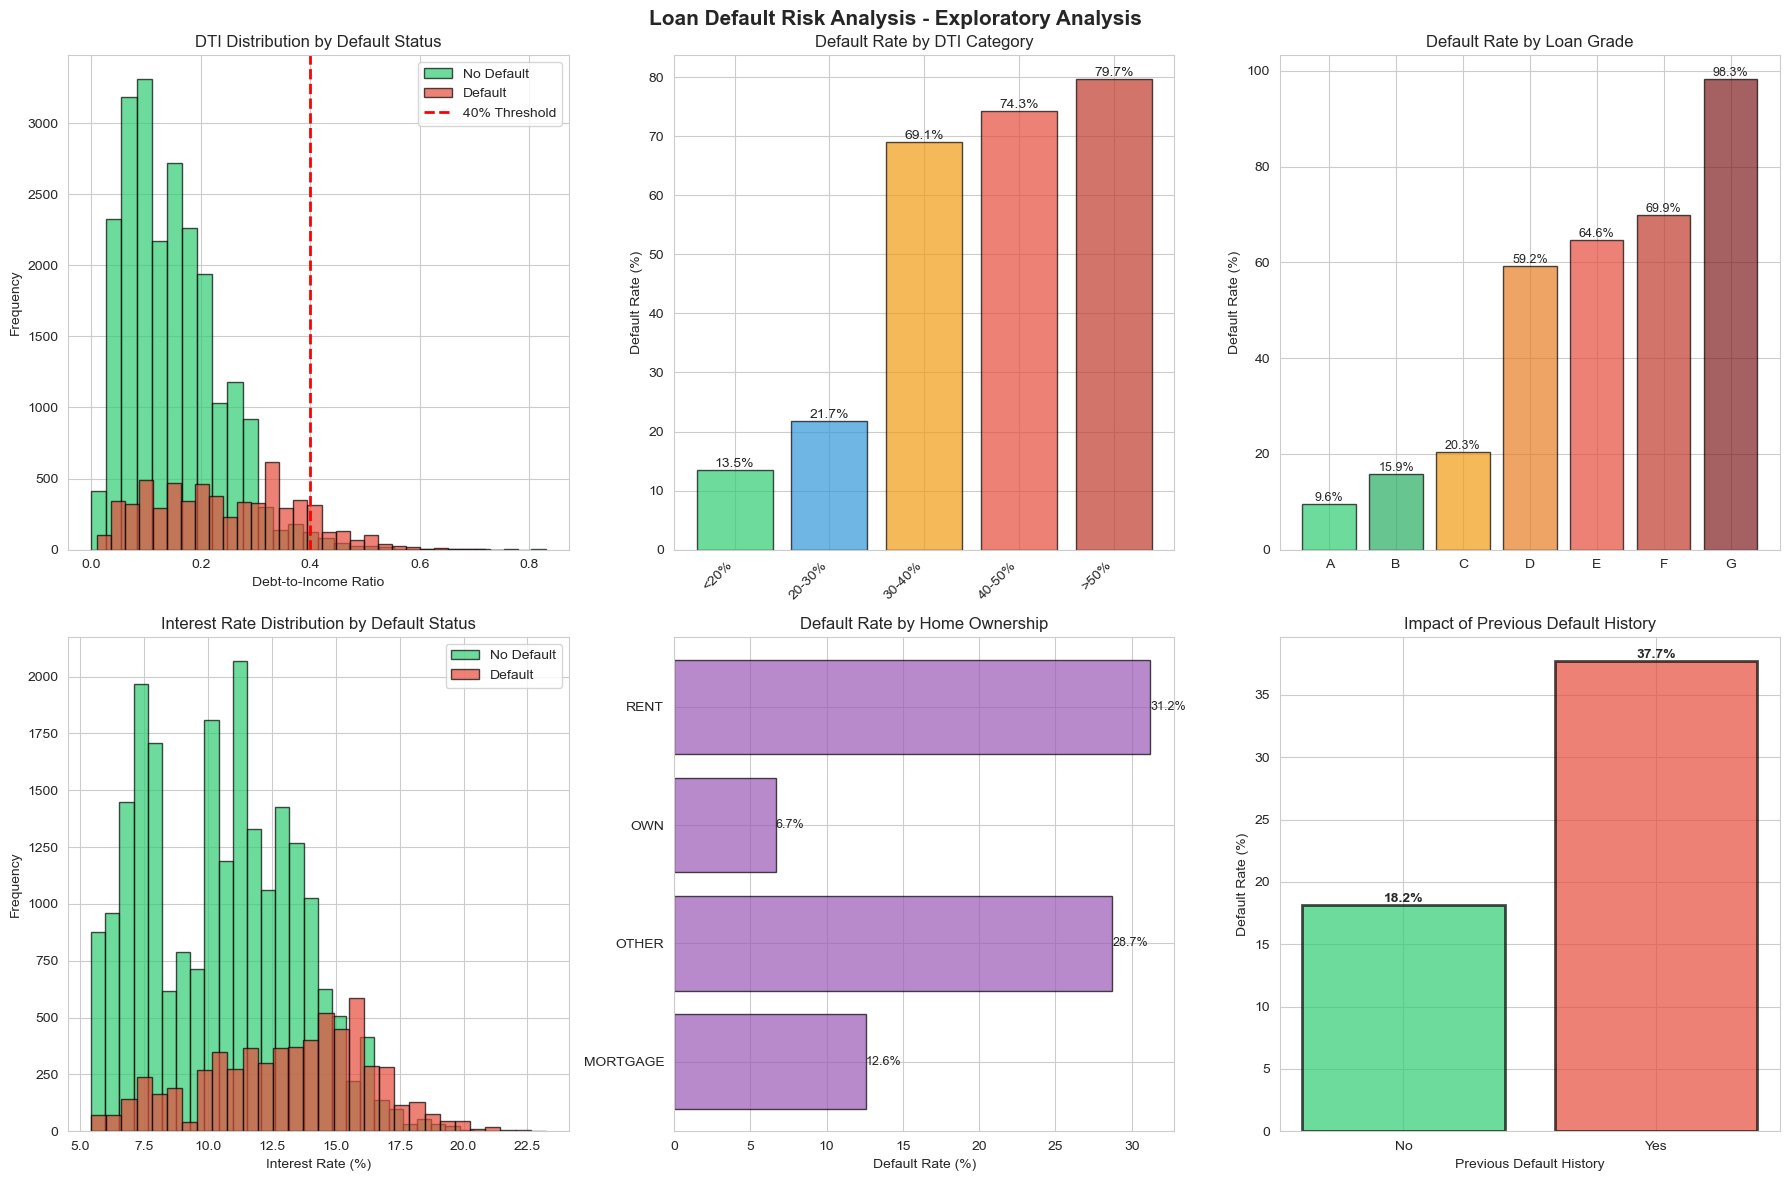

In [13]:
fig, axes = plt.subplots(2, 3, figsize=(18, 12))
fig.suptitle('Loan Default Risk Analysis - Exploratory Analysis', 
             fontsize=15, fontweight='bold')

# 1. DTI Distribution by Default Status
ax1 = axes[0, 0]
ax1.hist(non_defaulters['loan_percent_income'], bins=30, alpha=0.7, 
         label='No Default', color='#2ecc71', edgecolor='black')
ax1.hist(defaulters['loan_percent_income'], bins=30, alpha=0.7, 
         label='Default', color='#e74c3c', edgecolor='black')
ax1.axvline(0.4, color='red', linestyle='--', linewidth=2, label='40% Threshold')
ax1.set_xlabel('Debt-to-Income Ratio')
ax1.set_ylabel('Frequency')
ax1.set_title('DTI Distribution by Default Status')
ax1.legend()

# 2. Default Rate by DTI Category
ax2 = axes[0, 1]
dti_rates = df.groupby('dti_category')['loan_status'].mean() * 100
colors = ['#2ecc71', '#3498db', '#f39c12', '#e74c3c', '#c0392b']
ax2.bar(range(len(dti_rates)), dti_rates.values, color=colors, alpha=0.7, edgecolor='black')
ax2.set_xticks(range(len(dti_rates)))
ax2.set_xticklabels(dti_rates.index, rotation=45, ha='right')
ax2.set_ylabel('Default Rate (%)')
ax2.set_title('Default Rate by DTI Category')
for i, v in enumerate(dti_rates.values):
    ax2.text(i, v, f'{v:.1f}%', ha='center', va='bottom')

# 3. Default Rate by Loan Grade
ax3 = axes[0, 2]
grade_rates = df.groupby('loan_grade')['loan_status'].mean() * 100
grade_rates = grade_rates.sort_index()
colors_grade = ['#2ecc71', '#27ae60', '#f39c12', '#e67e22', '#e74c3c', '#c0392b', '#7f1c1f']
ax3.bar(range(len(grade_rates)), grade_rates.values, color=colors_grade, alpha=0.7, edgecolor='black')
ax3.set_xticks(range(len(grade_rates)))
ax3.set_xticklabels(grade_rates.index)
ax3.set_ylabel('Default Rate (%)')
ax3.set_title('Default Rate by Loan Grade')
for i, v in enumerate(grade_rates.values):
    ax3.text(i, v, f'{v:.1f}%', ha='center', va='bottom', fontsize=9)

# 4. Interest Rate Distribution
ax4 = axes[1, 0]
ax4.hist(non_defaulters['loan_int_rate'], bins=30, alpha=0.7, 
         label='No Default', color='#2ecc71', edgecolor='black')
ax4.hist(defaulters['loan_int_rate'], bins=30, alpha=0.7, 
         label='Default', color='#e74c3c', edgecolor='black')
ax4.set_xlabel('Interest Rate (%)')
ax4.set_ylabel('Frequency')
ax4.set_title('Interest Rate Distribution by Default Status')
ax4.legend()

# 5. Default Rate by Home Ownership
ax5 = axes[1, 1]
home_rates = df.groupby('person_home_ownership')['loan_status'].mean() * 100
ax5.barh(range(len(home_rates)), home_rates.values, color='#9b59b6', alpha=0.7, edgecolor='black')
ax5.set_yticks(range(len(home_rates)))
ax5.set_yticklabels(home_rates.index)
ax5.set_xlabel('Default Rate (%)')
ax5.set_title('Default Rate by Home Ownership')
for i, v in enumerate(home_rates.values):
    ax5.text(v, i, f'{v:.1f}%', ha='left', va='center', fontsize=9)

# 6. Previous Default Impact
ax6 = axes[1, 2]
prev_def_rates = df.groupby('cb_person_default_on_file')['loan_status'].mean() * 100
ax6.bar(['No', 'Yes'], prev_def_rates.values, color=['#2ecc71', '#e74c3c'], 
        alpha=0.7, edgecolor='black', linewidth=2)
ax6.set_xlabel('Previous Default History')
ax6.set_ylabel('Default Rate (%)')
ax6.set_title('Impact of Previous Default History')
for i, v in enumerate(prev_def_rates.values):
    ax6.text(i, v, f'{v:.1f}%', ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.show()

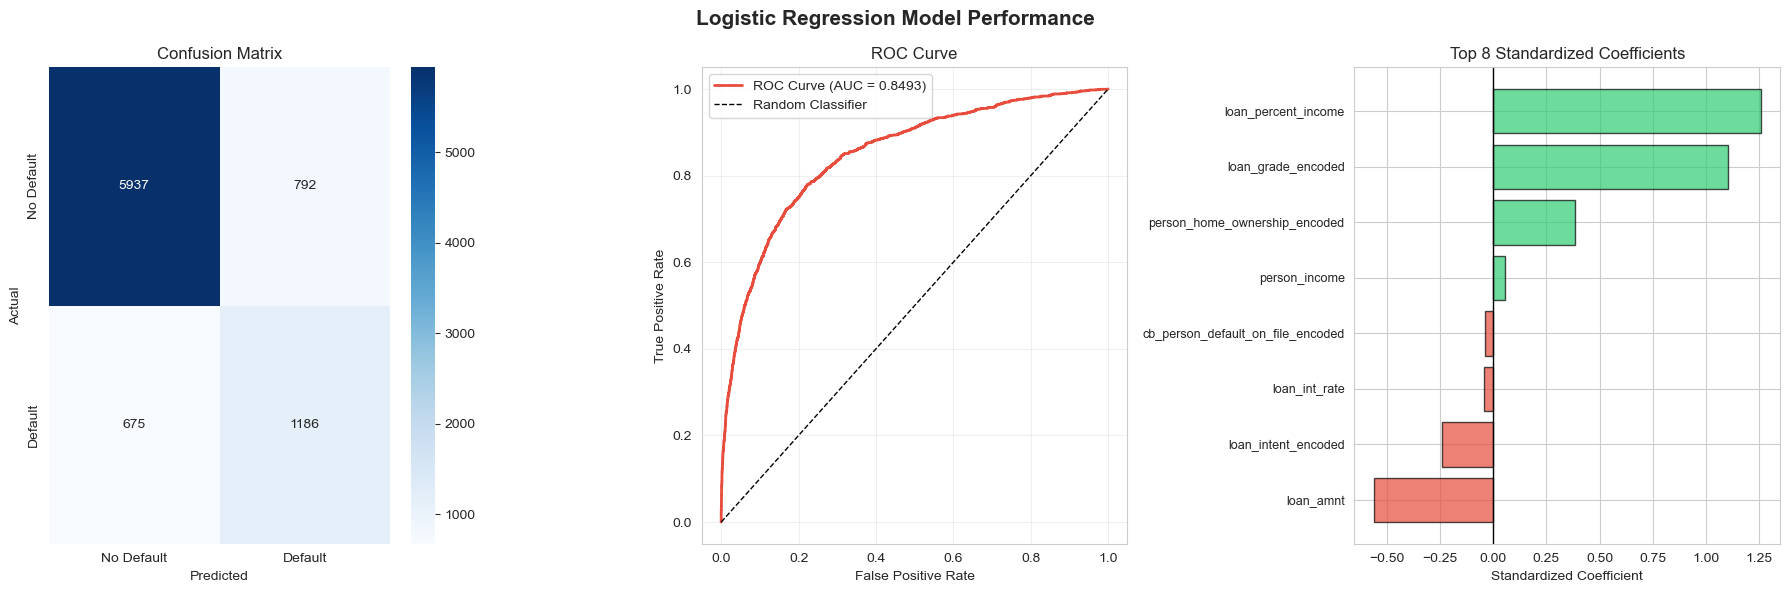

In [14]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle('Logistic Regression Model Performance', fontsize=15, fontweight='bold')

# 1. Confusion Matrix
ax1 = axes[0]
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax1, 
            xticklabels=['No Default', 'Default'],
            yticklabels=['No Default', 'Default'])
ax1.set_xlabel('Predicted')
ax1.set_ylabel('Actual')
ax1.set_title('Confusion Matrix')

# 2. ROC Curve
ax2 = axes[1]
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)
ax2.plot(fpr, tpr, color='#e74c3c', linewidth=2, label=f'ROC Curve (AUC = {roc_auc:.4f})')
ax2.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Random Classifier')
ax2.set_xlabel('False Positive Rate')
ax2.set_ylabel('True Positive Rate')
ax2.set_title('ROC Curve')
ax2.legend()
ax2.grid(True, alpha=0.3)

# 3. Feature Importance
ax3 = axes[2]
top_features = feature_importance.head(8).sort_values('Coefficient')
colors_feat = ['#e74c3c' if x < 0 else '#2ecc71' for x in top_features['Coefficient']]
ax3.barh(range(len(top_features)), top_features['Coefficient'], color=colors_feat, alpha=0.7, edgecolor='black')
ax3.set_yticks(range(len(top_features)))
ax3.set_yticklabels(top_features['Feature'], fontsize=9)
ax3.set_xlabel('Standardized Coefficient')
ax3.set_title('Top 8 Standardized Coefficients')
ax3.axvline(0, color='black', linewidth=1)

plt.tight_layout()
plt.show()

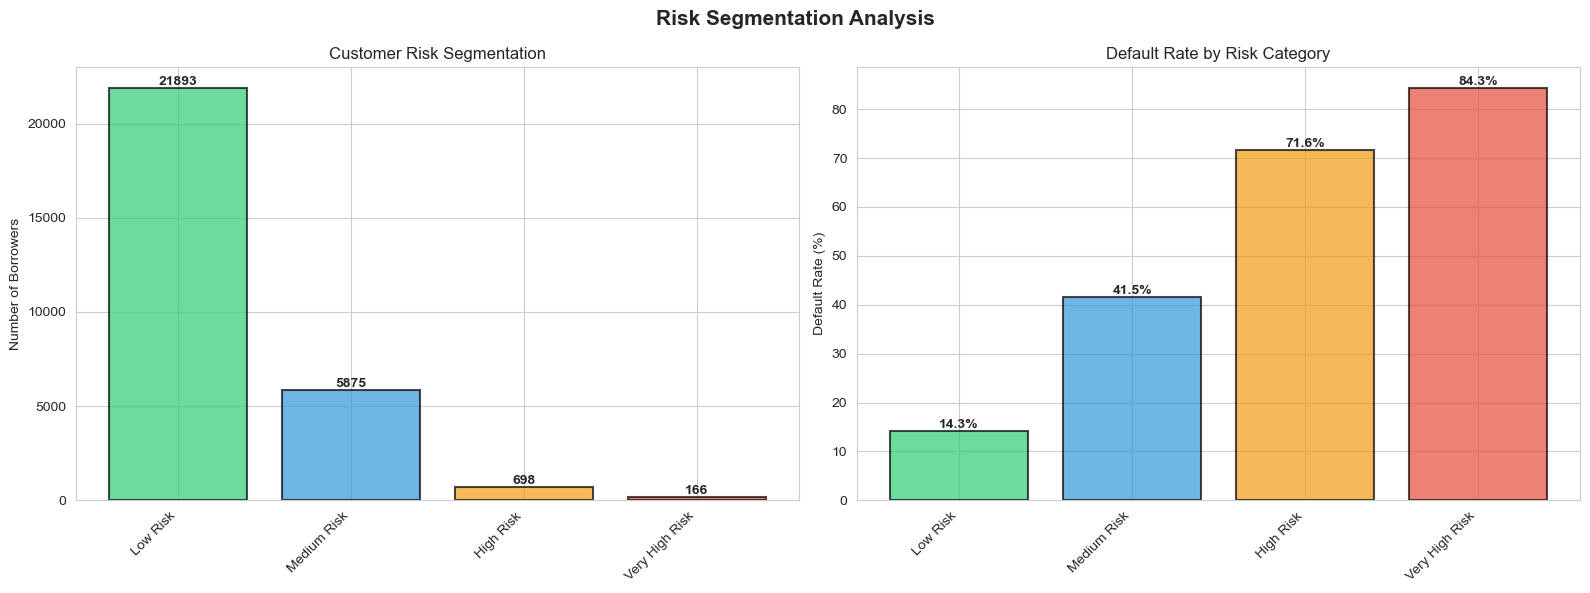

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Risk Segmentation Analysis', fontsize=15, fontweight='bold')

# Risk Category Distribution
ax1 = axes[0]
risk_counts = df['risk_category'].value_counts()
risk_counts = risk_counts.reindex(risk_order)
colors_risk = ['#2ecc71', '#3498db', '#f39c12', '#e74c3c']
bars = ax1.bar(range(len(risk_counts)), risk_counts.values, color=colors_risk, 
               alpha=0.7, edgecolor='black', linewidth=1.5)
ax1.set_xticks(range(len(risk_counts)))
ax1.set_xticklabels(risk_order, rotation=45, ha='right')
ax1.set_ylabel('Number of Borrowers')
ax1.set_title('Customer Risk Segmentation')
for bar in bars:
    height = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2., height,
             f'{int(height)}', ha='center', va='bottom', fontweight='bold')

# Default Rate by Risk Category
ax2 = axes[1]
risk_default_rates = df.groupby('risk_category')['loan_status'].mean() * 100
risk_default_rates = risk_default_rates.reindex(risk_order)
bars = ax2.bar(range(len(risk_default_rates)), risk_default_rates.values, 
               color=colors_risk, alpha=0.7, edgecolor='black', linewidth=1.5)
ax2.set_xticks(range(len(risk_default_rates)))
ax2.set_xticklabels(risk_order, rotation=45, ha='right')
ax2.set_ylabel('Default Rate (%)')
ax2.set_title('Default Rate by Risk Category')
for bar in bars:
    height = bar.get_height()
    ax2.text(bar.get_x() + bar.get_width()/2., height,
             f'{height:.1f}%', ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.show()

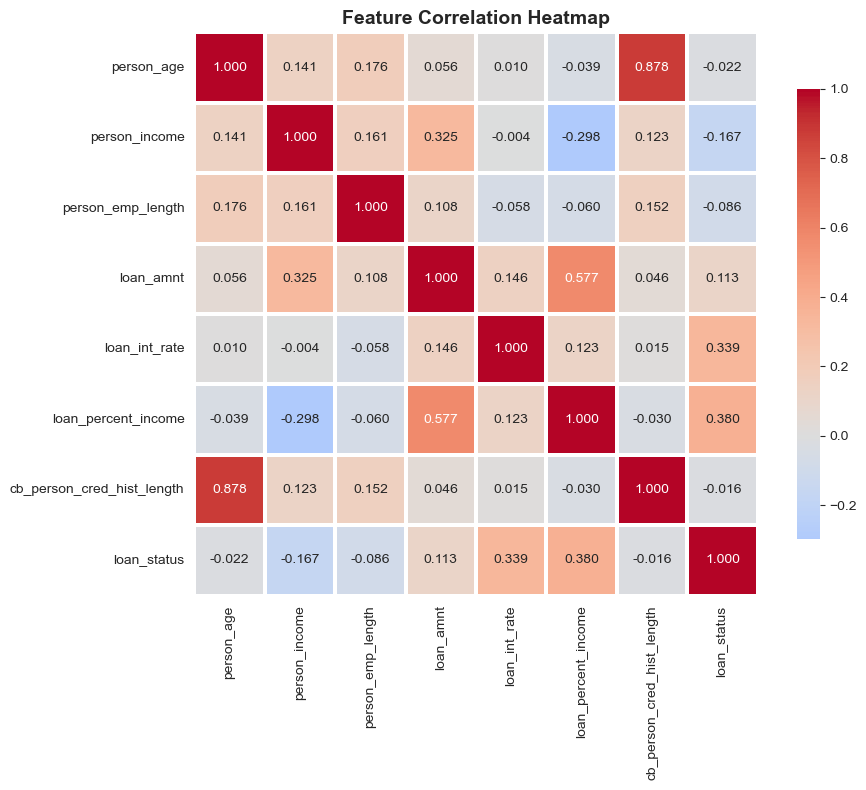

In [16]:
# Select numerical columns for correlation
numerical_cols = ['person_age', 'person_income', 'person_emp_length', 
                  'loan_amnt', 'loan_int_rate', 'loan_percent_income',
                  'cb_person_cred_hist_length', 'loan_status']

correlation_matrix = df[numerical_cols].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, fmt='.3f', cmap='coolwarm', 
            center=0, square=True, linewidths=1.5, cbar_kws={"shrink": 0.8})
plt.title('Feature Correlation Heatmap', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [17]:
print("=" * 60)
print("SUMMARY OF KEY FINDINGS")
print("=" * 60)

print(f"\n1. Dataset Overview:")
print(f"   - Total records: {len(df):,}")
print(f"   - Overall default rate: {default_rate:.2f}%")

print(f"\n2. Debt-to-Income Ratio (Critical Finding):")
print(f"   - DTI <= 40%: {low_dti['loan_status'].mean()*100:.2f}% default rate")
print(f"   - DTI > 40%: {high_dti['loan_status'].mean()*100:.2f}% default rate")
print(f"   - Risk multiplier: {high_dti['loan_status'].mean() / low_dti['loan_status'].mean():.2f}x")
print(f"   - Statistical significance: p < 0.001")

print(f"\n3. Logistic Regression Model Performance:")
print(f"   - Accuracy: {accuracy:.4f} ({accuracy*100:.2f}%)")
print(f"   - ROC-AUC Score: {roc_auc:.4f}")
print(f"   - Precision: {precision:.4f}")
print(f"   - Recall: {recall:.4f}")
print(f"   - F1-Score: {f1:.4f}")

print(f"\n4. Largest Standardized Coefficients:")
top_5_features = feature_importance.head(5)
for i, row in top_5_features.iterrows():
    print(f"   {i+1}. {row['Feature']}: {row['Coefficient']:.4f}")
print("   Coefficients are on the standardized feature scale, so they are directly")
print("   comparable: each is the change in log-odds per one standard deviation move")
print("   in that feature. The DTI ratio and prior-default finding above remain the")
print("   more interpretable risk signals for a business audience.")

print(f"\n5. Risk Segmentation:")
for category in risk_order:
    if category in risk_summary.index:
        count = int(risk_summary.loc[category, 'Count'])
        rate = risk_summary.loc[category, 'Default_Rate']
        pct = count / len(df) * 100
        print(f"   - {category}: {count:,} borrowers ({pct:.1f}%) - {rate:.1f}% default rate")

print(f"\n6. Other Key Findings:")
prev_default_multiplier = prev_def_rates.iloc[1] / prev_def_rates.iloc[0]
print(f"   - Previous default history increases risk by {prev_default_multiplier:.2f}x")
high_grade_default = grade_rates.iloc[-2:].mean()
print(f"   - Loan grades F-G show highest default rates ({high_grade_default:.1f}%)")
print(f"   - Higher interest rates strongly correlate with default risk")

print(f"\n7. Business Recommendations:")
print("   - Implement strict DTI threshold at 40% for loan approval")
print("   - Use logistic regression model for real-time risk assessment")
print("   - Apply risk-based pricing based on segmentation framework")
print("   - Require additional collateral for High/Very High Risk borrowers")
print("   - Offer lower rates to Low Risk segments for customer retention")
print("   - Focus underwriting scrutiny on borrowers with previous defaults")

print("\n" + "=" * 60)
print("ANALYSIS COMPLETE")
print("=" * 60)
print("\nAnalysis includes:")
print("  ✓ Data cleaning and exploration")
print("  ✓ DTI ratio analysis with 40% threshold")
print(f"  ✓ Logistic regression model (ROC-AUC = {roc_auc:.4f})")
print("  ✓ Risk scoring framework")
print("  ✓ Comprehensive visualizations")
print("  ✓ Business recommendations")
print("=" * 60)

SUMMARY OF KEY FINDINGS

1. Dataset Overview:
   - Total records: 28,632
   - Overall default rate: 21.66%

2. Debt-to-Income Ratio (Critical Finding):
   - DTI <= 40%: 19.79% default rate
   - DTI > 40%: 75.52% default rate
   - Risk multiplier: 3.82x
   - Statistical significance: p < 0.001

3. Logistic Regression Model Performance:
   - Accuracy: 0.8292 (82.92%)
   - ROC-AUC Score: 0.8493
   - Precision: 0.5996
   - Recall: 0.6373
   - F1-Score: 0.6179

4. Largest Standardized Coefficients:
   6. loan_percent_income: 1.2568
   10. loan_grade_encoded: 1.1046
   4. loan_amnt: -0.5614
   8. person_home_ownership_encoded: 0.3827
   9. loan_intent_encoded: -0.2388
   Coefficients are on the standardized feature scale, so they are directly
   comparable: each is the change in log-odds per one standard deviation move
   in that feature. The DTI ratio and prior-default finding above remain the
   more interpretable risk signals for a business audience.

5. Risk Segmentation:
   - Low Risk: 